# Koalas_Dask - Medium Dataset

**Summary of this Notebook:**

This notebook presents a comprehensive performance benchmarking study comparing Koalas (based on PySpark) and Dask, two popular distributed data processing frameworks in Python. The evaluation was conducted using the medium dataset.

The benchmarking includes a diverse set of operations to understand how each framework performs under different scenarios:

Standard Operations: A baseline comparison covering typical data processing tasks such as arithmetic operations, joins, groupby statistics, and file reading.

Filtering: Operations were executed on filtered datasets to reflect real-world usage where data is often subsetted based on specific conditions.

Filtering with Caching: To assess the impact of in-memory optimizations, we repeated the filtered operations with caching enabled.

Each test measured execution time across both frameworks, and results were compared using both absolute timings and relative performance ratios. The goal is to identify strengths and weaknesses in each framework’s execution model and provide guidance on their suitability for different data processing tasks.

In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet("Samples/balanced_medium.parquet")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190009 entries, 0 to 2190008
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   vendor_name            object        
 1   Trip_Pickup_DateTime   datetime64[ns]
 2   Trip_Dropoff_DateTime  object        
 3   Passenger_Count        int64         
 4   Trip_Distance          float64       
 5   Start_Lon              float64       
 6   Start_Lat              float64       
 7   End_Lon                float64       
 8   End_Lat                float64       
 9   Payment_Type           object        
 10  Fare_Amt               float64       
 11  surcharge              float64       
 12  Tip_Amt                float64       
 13  Tolls_Amt              float64       
 14  Total_Amt              float64       
 15  year                   int64         
 16  month                  int64         
 17  day                    int64         
 18  hour                  

**Load and Clean Dataset**

The dataset is first loaded using Pandas and its index is reset to avoid hidden columns.
Then, a cleaned version is saved as a new .parquet file to ensure consistency before benchmarking.

In [4]:
# Step 1: Load with Pandas and reset index
df = pd.read_parquet("Samples/balanced_medium.parquet")
df = df.reset_index()  # Ensures no hidden index column remains

# Step 2: Save a clean version
df.to_parquet("Samples/sample_2009_2010_medium_clean.parquet", index=False)

# Benchmark 

**Prepare Koalas Environment with PySpark Compatibility**

To ensure compatibility between workers and driver, both are explicitly set to use the same Python version (3.7).
The JAVA_HOME path is also defined to properly run Spark-based operations in the environment.

**Set-up**

In [ ]:
# ENSURE THAT WORKERS AND DRIVER RUN THE SAME PYTHON VERSION

import os
import sys

# Set both to the same Python version
os.environ["PYSPARK_PYTHON"] = "/opt/conda/envs/cdle/bin/python3.7"
os.environ["PYSPARK_DRIVER_PYTHON"] = "/opt/conda/envs/cdle/bin/python3.7"
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

print(sys.executable)
print(sys.version)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

/opt/conda/envs/cdle/bin/python
3.7.12 | packaged by conda-forge | (default, Oct 26 2021, 06:08:21) 
[GCC 9.4.0]


**Initialize Spark Session and Configure Runtime**

A Spark session is initialized with specific Python executables to match PySpark requirements.
Additionally, the Databricks I/O cache is disabled to measure raw execution times without caching effects.

In [ ]:
from pyspark.sql import SparkSession

# Initialize Spark session with defined Python executables
spark = SparkSession.builder \
    .appName("project") \
    .config("spark.pyspark.python", "/usr/bin/python3.7") \
    .config("spark.pyspark.driver.python", "/usr/bin/python3.7") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

# Disable caching to benchmark raw performance
spark.conf.set("spark.databricks.io.cache.enabled", "false")
print("spark.databricks.io.cache.enabled is %s" % spark.conf.get("spark.databricks.io.cache.enabled"))

spark.databricks.io.cache.enabled is false


In [8]:
print(spark.sparkContext.getConf().get("spark.pyspark.python"))
print(spark.sparkContext.getConf().get("spark.pyspark.driver.python"))

/usr/bin/python3.7
/usr/bin/python3.7


**Import Required Libraries and Verify Environment Versions**

All necessary libraries—pandas, numpy, koalas, dask, pyarrow, pyspark—are imported.
Library versions are printed to ensure consistency and reproducibility across benchmarks.

FutureWarnings are suppressed to keep the output clean and focused during benchmarking.
This avoids noise in logs, especially when using evolving libraries like Koalas and Dask.

In [ ]:
# Import all required libraries and check versions
import pandas as pd
import numpy as np
import pyspark
import pyarrow
import databricks.koalas as ks
import dask.dataframe as dd
from dask.distributed import Client, LocalCluster
 
print('pandas version: %s' % pd.__version__)
print('numpy version: %s' % np.__version__)
print('koalas version: %s' % ks.__version__)
print("pyspark version:", pyspark.__version__)
print("pyarrow version:", pyarrow.__version__)

import dask
print('dask version: %s' % dask.__version__)
 
import time

pandas version: 1.1.5
numpy version: 1.19.5
koalas version: 1.7.0
pyspark version: 3.4.4
pyarrow version: 1.0.1
dask version: 2022.02.0


**Benchmark**

Benchmarking was performed on each operation using the custom benchmark function.
This function recorded the execution time of each task on the Koalas DataFrame and stored the results for later analysis. It enabled a systematic comparison of operation durations across different processing scenarios.

In [10]:
def benchmark(f, df, benchmarks, name, **kwargs):
    """Benchmark the given function against the given DataFrame.
    
    Parameters
    ----------
    f: function to benchmark
    df: data frame
    benchmarks: container for benchmark results
    name: task name
    
    Returns
    -------
    Duration (in seconds) of the given operation
    """
    start_time = time.time()
    ret = f(df, **kwargs)
    benchmarks['duration'].append(time.time() - start_time)
    benchmarks['task'].append(name)
    print(f"{name} took: {benchmarks['duration'][-1]} seconds")
    return benchmarks['duration'][-1]
 
def get_results(benchmarks):
    """Return a pandas DataFrame containing benchmark results."""
    return pd.DataFrame.from_dict(benchmarks)

# Dataset Information
#### Regular Dataset


The clean Parquet dataset was loaded using Koalas.

Three separate benchmark containers were initialized (koalas_benchmarks, koalas_benchmarks_filtered, and koalas_benchmarks_cache) to store execution times for the full, filtered, and cached scenarios respectively.

In [ ]:
# Load cleaned dataset with Koalas
koalas_data = ks.read_parquet("Samples/sample_2009_2010_medium_clean.parquet")

# Initialize benchmark containers for each scenario
koalas_benchmarks = {
    'duration': [],  # in seconds
    'task': [],
}

koalas_benchmarks_filtered = {
    'duration': [],  # in seconds
    'task': [],
}

koalas_benchmarks_cache = {
    'duration': [],  # in seconds
    'task': [],
}

In [ ]:
koalas_data.info()

<class 'databricks.koalas.frame.DataFrame'>
Int64Index: 2190009 entries, 0 to 2190008
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   index                  2190009 non-null  int64         
 1   vendor_name            2190009 non-null  object        
 2   Trip_Pickup_DateTime   2190009 non-null  datetime64[ns]
 3   Trip_Dropoff_DateTime  2190009 non-null  object        
 4   Passenger_Count        2190009 non-null  int64         
 5   Trip_Distance          2190009 non-null  float64       
 6   Start_Lon              2190009 non-null  float64       
 7   Start_Lat              2190009 non-null  float64       
 8   End_Lon                2190009 non-null  float64       
 9   End_Lat                2190009 non-null  float64       
 10  Payment_Type           2190009 non-null  object        
 11  Fare_Amt               2190009 non-null  float64       
 12  surcharge             

In [ ]:
# Display the first 10 rows of the loaded Koalas DataFrame
koalas_data.head(10)

,index,vendor_name,Trip_Pickup_DateTime,Trip_Dropoff_DateTime,Passenger_Count,Trip_Distance,Start_Lon,Start_Lat,End_Lon,End_Lat,Payment_Type,Fare_Amt,surcharge,Tip_Amt,Tolls_Amt,Total_Amt,year,month,day,hour
0,0,CMT,2009-01-01 00:45:16,2009-01-01 01:01:48,1,4.8,-73.955986,40.776054,-73.978488,40.728903,Cash,15.0,0.0,0.00,0.0,15.00,2009,1,1,0
1,1,CMT,2009-01-01 00:30:50,2009-01-01 00:34:37,1,0.4,-73.993314,40.744723,-73.985561,40.741991,Cash,4.6,0.0,0.00,0.0,4.60,2009,1,1,0
2,2,CMT,2009-01-01 00:39:49,2009-01-01 00:47:58,1,1.9,-73.969583,40.769001,-73.975622,40.787921,Cash,7.8,0.0,0.00,0.0,7.80,2009,1,1,0
3,3,CMT,2009-01-01 00:47:32,2009-01-01 00:56:22,1,1.6,-73.950814,40.779275,-73.965337,40.759277,Cash,7.8,0.0,0.00,0.0,7.80,2009,1,1,0
4,4,CMT,2009-01-01 00:26:15,2009-01-01 00:26:38,1,0.1,-73.926332,40.808143,-73.928372,40.808988,Cash,3.0,0.0,0.00,0.0,3.00,2009,1,1,0
5,5,CMT,2009-01-01 00:38:29,2009-01-01 00:59:03,3,7.8,-74.003245,40.733577,-73.963703,40.810218,Credit,21.0,0.0,5.25,0.0,26.25,2009,1,1,0
6,6,CMT,2009-01-01 00:41:06,2009-01-01 00:50:13,2,1.0,-73.990086,40.740832,-73.980446,40.746520,Cash,7.0,0.0,0.00,0.0,7.00,2009,1,1,0
7,7,DDS,2009-01-01 00:11:46,2009-01-01 00:25:06,2,1.6,-73.994876,40.755437,-73.983055,40.739024,CREDIT,8.1,0.5,2.00,0.0,10.60,2009,1,1,0
8,8,CMT,2009-01-01 00:36:12,2009-01-01 01:10:28,2,5.6,-73.953678,40.784593,-73.983188,40.729943,Cash,21.4,0.0,0.00,0.0,21.40,2009,1,1,0
9,9,CMT,2009-01-01 00:02:14,2009-01-01 00:09:26,1,1.5,-74.001634,40.730793,-73.991639,40.748866,Cash,6.6,0.0,0.00,0.0,6.60,2009,1,1,0


#### Standard Operations

A set of data processing functions was defined for benchmarking purposes.
These functions cover common operations such as aggregations, arithmetic computations, statistical summaries, groupby operations, and joins, enabling performance evaluation across a variety of tasks.


In [ ]:
# Define a set of utility functions to perform various data operations for benchmarking

def read_file_parquet(df=None):
    return ks.read_parquet("Samples/sample_2009_2010_medium_clean.parquet")

def count(df=None):
    return len(df)
 
def count_index_length(df=None):
    return len(df.index)
 
def mean(df):
    return df.Fare_Amt.mean()
 
def standard_deviation(df):
    return df.Fare_Amt.std()
 
def mean_of_sum(df):
    return (df.Fare_Amt + df.Tip_Amt).mean()
 
def sum_columns(df):
    x = df.Fare_Amt + df.Tip_Amt
    x.to_pandas()
    return x
 
def mean_of_product(df):
    return (df.Fare_Amt * df.Tip_Amt).mean()
 
def product_columns(df):
    x = df.Fare_Amt * df.Tip_Amt
    x.to_pandas()
    return x
 
def value_counts(df):
    val_counts = df.Fare_Amt.value_counts()
    val_counts.to_pandas()
    return val_counts
  
def complicated_arithmetic_operation(df):
    theta_1 = df.Start_Lon
    phi_1 = df.Start_Lat
    theta_2 = df.End_Lon
    phi_2 = df.End_Lat
    temp = (np.sin((theta_2 - theta_1) / 2 * np.pi / 180) ** 2
           + np.cos(theta_1 * np.pi / 180) * np.cos(theta_2 * np.pi / 180) * np.sin((phi_2 - phi_1) / 2 * np.pi / 180) ** 2)
    ret = np.multiply(np.arctan2(np.sqrt(temp), np.sqrt(1-temp)),2)
    ret.to_pandas()
    return ret
  
def mean_of_complicated_arithmetic_operation(df):
    theta_1 = df.Start_Lon
    phi_1 = df.Start_Lat
    theta_2 = df.End_Lon
    phi_2 = df.End_Lat
    temp = (np.sin((theta_2 - theta_1) / 2 * np.pi / 180) ** 2
           + np.cos(theta_1 * np.pi / 180) * np.cos(theta_2 * np.pi / 180) * np.sin((phi_2 - phi_1) / 2 * np.pi / 180) ** 2)
    ret = np.multiply(np.arctan2(np.sqrt(temp), np.sqrt(1-temp)),2) 
    return ret.mean()
  
def groupby_statistics(df):
    gb = df.groupby(by='Passenger_Count').agg(
      {
        'Fare_Amt': ['mean', 'std'], 
        'Tip_Amt': ['mean', 'std']
      }
    )
    gb.to_pandas()
    return gb

# Create helper dataframe for joining
other = ks.DataFrame(groupby_statistics(koalas_data).to_pandas())
other.columns = pd.Index([e[0]+'_' + e[1] for e in other.columns.tolist()])
 
def join_count(df, other):
    return len(df.merge(other.spark.hint("broadcast"), left_index=True, right_index=True))
 
def join_data(df, other):
    ret = df.merge(other.spark.hint("broadcast"), left_index=True, right_index=True)
    ret.to_pandas()
    return ret

After that, each function was benchmarked using the benchmark() utility.
The tasks were applied to the Koalas DataFrame and their execution durations were stored in the koalas_benchmarks container for later analysis and visualization.

In [ ]:
# Apply each operation and record benchmark using the utility function
benchmark(read_file_parquet, df=None, benchmarks=koalas_benchmarks, name='read file')
benchmark(count, df=koalas_data, benchmarks=koalas_benchmarks, name='count')
benchmark(count_index_length, df=koalas_data, benchmarks=koalas_benchmarks, name='count index length')
benchmark(mean, df=koalas_data, benchmarks=koalas_benchmarks, name='mean')
benchmark(standard_deviation, df=koalas_data, benchmarks=koalas_benchmarks, name='standard deviation')
benchmark(mean_of_sum, df=koalas_data, benchmarks=koalas_benchmarks, name='mean of columns addition')
benchmark(sum_columns, df=koalas_data, benchmarks=koalas_benchmarks, name='addition of columns')
benchmark(mean_of_product, df=koalas_data, benchmarks=koalas_benchmarks, name='mean of columns multiplication')
benchmark(product_columns, df=koalas_data, benchmarks=koalas_benchmarks, name='multiplication of columns')
benchmark(value_counts, df=koalas_data, benchmarks=koalas_benchmarks, name='value counts')
benchmark(complicated_arithmetic_operation, df=koalas_data, benchmarks=koalas_benchmarks, name='complex arithmetic ops')
benchmark(mean_of_complicated_arithmetic_operation, df=koalas_data, benchmarks=koalas_benchmarks, name='mean of complex arithmetic ops')
benchmark(groupby_statistics, df=koalas_data, benchmarks=koalas_benchmarks, name='groupby statistics')
benchmark(join_count, koalas_data, benchmarks=koalas_benchmarks, name='join count', other=other)
benchmark(join_data, koalas_data, benchmarks=koalas_benchmarks, name='join', other=other)

read file took: 0.17547845840454102 seconds
count took: 0.09752345085144043 seconds
count index length took: 0.09006953239440918 seconds
mean took: 0.18075966835021973 seconds
standard deviation took: 0.22653579711914062 seconds
mean of columns addition took: 0.19525837898254395 seconds


addition of columns took: 8.567658185958862 seconds
mean of columns multiplication took: 0.23471665382385254 seconds


multiplication of columns took: 8.457660436630249 seconds
value counts took: 0.7529957294464111 seconds


complex arithmetic ops took: 9.319678783416748 seconds
mean of complex arithmetic ops took: 1.8027336597442627 seconds
groupby statistics took: 0.3840181827545166 seconds


join count took: 1.3434967994689941 seconds


join took: 6.902164936065674 seconds


6.902164936065674

**Save results**

The results were retrieved from the benchmark dictionary and duplicates were removed.
The results were indexed by task name and stored in a DataFrame for exporting.

The DataFrame was saved as a Parquet file for later access.
This allows for efficient, structured storage of benchmarking results.

In [ ]:
# Retrieve benchmark results and remove duplicate task entries
koalas_res_temp = get_results(koalas_benchmarks).drop_duplicates(subset='task').set_index('task')

# Print the result DataFrame
print(koalas_res_temp)

# Define the file path for saving
filename = 'Results_M/koalas_local'

# Save the result DataFrame as a Parquet file
koalas_res_temp.to_parquet(filename)

print(f'O arquivo Parquet foi salvo em {filename}.')

                                duration
task                                    
read file                       0.175478
count                           0.097523
count index length              0.090070
mean                            0.180760
standard deviation              0.226536
mean of columns addition        0.195258
addition of columns             8.567658
mean of columns multiplication  0.234717
multiplication of columns       8.457660
value counts                    0.752996
complex arithmetic ops          9.319679
mean of complex arithmetic ops  1.802734
groupby statistics              0.384018
join count                      1.343497
join                            6.902165
O arquivo Parquet foi salvo em Results_M/koalas_local.


## Operations with filtering

This section filters the dataset to include only rows where the Tip_Amt is between 1 and 5.

All benchmark functions are then re-executed on this filtered subset. 
This provides insights into how Koalas handles filtered subsets compared to the full dataset.

In [17]:
expr_filter = (koalas_data.Tip_Amt >= 1) & (koalas_data.Tip_Amt <= 5)
 
def filter_data(df):
    return df[expr_filter]
 
koalas_filtered = filter_data(koalas_data)

In [18]:
benchmark(read_file_parquet, df=None, benchmarks=koalas_benchmarks_filtered, name='read file')
benchmark(count, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='count')
benchmark(count_index_length, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='count index length')
benchmark(mean, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='mean')
benchmark(standard_deviation, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='standard deviation')
benchmark(mean_of_sum, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name ='mean of columns addition')
benchmark(sum_columns, df=koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='addition of columns')
benchmark(mean_of_product, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name ='mean of columns multiplication')
benchmark(product_columns, df=koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='multiplication of columns')
benchmark(mean_of_complicated_arithmetic_operation, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='mean of complex arithmetic ops')
benchmark(complicated_arithmetic_operation, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='complex arithmetic ops')
benchmark(value_counts, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name ='value counts')
benchmark(groupby_statistics, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='groupby statistics')
 
other = ks.DataFrame(groupby_statistics(koalas_filtered).to_pandas())
other.columns = pd.Index([e[0]+'_' + e[1] for e in other.columns.tolist()])
benchmark(join_data, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='join', other=other)
benchmark(join_count, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='join count', other=other)

read file took: 0.1291811466217041 seconds
count took: 0.20860862731933594 seconds
count index length took: 0.11954402923583984 seconds
mean took: 0.2281498908996582 seconds
standard deviation took: 0.2394270896911621 seconds
mean of columns addition took: 0.20872044563293457 seconds


addition of columns took: 2.7193214893341064 seconds
mean of columns multiplication took: 0.23333168029785156 seconds


multiplication of columns took: 3.484862804412842 seconds
mean of complex arithmetic ops took: 1.441589593887329 seconds


complex arithmetic ops took: 4.8695008754730225 seconds
value counts took: 0.40888071060180664 seconds
groupby statistics took: 0.3693547248840332 seconds


join took: 6.624686241149902 seconds
join count took: 1.3128166198730469 seconds


1.3128166198730469

**Save Results**

In [19]:
# Obter os resultados e remover duplicatas
koalas_res_filtered = get_results(koalas_benchmarks_filtered).drop_duplicates(subset='task').set_index('task')

# Print dos dataframes
print(koalas_res_filtered)

# Definir o nome do arquivo ou diretório
filename_filter = 'Results_M/koalas_local_filtered'

# Salvar o DataFrame em formato Parquet
koalas_res_filtered.to_parquet(filename_filter)

print(f'O arquivo Parquet foi salvo em {filename_filter}.')

                                duration
task                                    
read file                       0.129181
count                           0.208609
count index length              0.119544
mean                            0.228150
standard deviation              0.239427
mean of columns addition        0.208720
addition of columns             2.719321
mean of columns multiplication  0.233332
multiplication of columns       3.484863
mean of complex arithmetic ops  1.441590
complex arithmetic ops          4.869501
value counts                    0.408881
groupby statistics              0.369355
join                            6.624686
join count                      1.312817
O arquivo Parquet foi salvo em Results_M/koalas_local_filtered.


## Operations with filtering and cache

This section applies caching to the filtered Koalas DataFrame using Spark’s cache mechanism.

Caching stores the filtered data in memory to speed up repeated operations on the same subset.

Benchmarks are re-run on the cached data to measure performance improvements gained by memory persistence.

The results are collected, duplicates removed, and then saved to a Parquet file for later analysis.

In [ ]:
# Add caching to the filtered DataFrame to persist data in memory
koalas_filtered = koalas_filtered.spark.cache()
print(f'Enforce caching: {len(koalas_filtered)} rows of filtered data')

Enforce caching: 569222 rows of filtered data


In [ ]:
# Re-run all benchmark tests on the cached filtered data
benchmark(read_file_parquet, df=None, benchmarks=koalas_benchmarks_cache, name='read file')
benchmark(count, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='count')
benchmark(count_index_length, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='count index length')
benchmark(mean, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='mean')
benchmark(standard_deviation, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='standard deviation')
benchmark(mean_of_sum, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='mean of columns addition')
benchmark(sum_columns, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='addition of columns')
benchmark(mean_of_product, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='mean of columns multiplication')
benchmark(product_columns, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='multiplication of columns')
benchmark(value_counts, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='value counts')
benchmark(complicated_arithmetic_operation, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='complex arithmetic ops')
benchmark(mean_of_complicated_arithmetic_operation, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='mean of complex arithmetic ops')
benchmark(groupby_statistics, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='groupby statistics')
benchmark(join_count, koalas_filtered, benchmarks=koalas_benchmarks_cache, name='join count', other=other)
benchmark(join_data, koalas_filtered, benchmarks=koalas_benchmarks_cache, name='join', other=other)

read file took: 0.12677669525146484 seconds
count took: 0.0412898063659668 seconds
count index length took: 0.04776144027709961 seconds
mean took: 0.12642502784729004 seconds
standard deviation took: 0.07825541496276855 seconds
mean of columns addition took: 0.10179543495178223 seconds
addition of columns took: 1.9386813640594482 seconds
mean of columns multiplication took: 0.10257363319396973 seconds
multiplication of columns took: 2.140676975250244 seconds
value counts took: 0.18800806999206543 seconds
complex arithmetic ops took: 3.2330563068389893 seconds
mean of complex arithmetic ops took: 1.3230340480804443 seconds
groupby statistics took: 0.27393221855163574 seconds
join count took: 0.4041481018066406 seconds
join took: 0.6772751808166504 seconds


0.6772751808166504

**Save results**

In [ ]:
# Obtain results, remove duplicate tasks, and set task as index
koalas_res_cache = get_results(koalas_benchmarks_cache).drop_duplicates(subset='task').set_index('task')

# Print the benchmark results
print(koalas_res_cache)

# Define output filename for cached results
filename_cache = 'Results_M/koalas_local_cache'

# Save results DataFrame as a Parquet file
koalas_res_cache.to_parquet(filename_cache)

print(f'O arquivo Parquet foi salvo em {filename_cache}.')

                                duration
task                                    
read file                       0.126777
count                           0.041290
count index length              0.047761
mean                            0.126425
standard deviation              0.078255
mean of columns addition        0.101795
addition of columns             1.938681
mean of columns multiplication  0.102574
multiplication of columns       2.140677
value counts                    0.188008
complex arithmetic ops          3.233056
mean of complex arithmetic ops  1.323034
groupby statistics              0.273932
join count                      0.404148
join                            0.677275
O arquivo Parquet foi salvo em Results_M/koalas_local_cache.


# Dask

This section reads the entire dataset from a Parquet file into a pandas DataFrame and then converts it into a Dask DataFrame with one partition.

A set of benchmark functions is defined to perform various operations on the Dask DataFrame. Each function uses Dask’s lazy evaluation and explicitly calls .compute() to trigger the actual computation.

After defining these functions, the code initializes a Dask client for parallel computation and runs all benchmark functions on the full Dask dataset, recording their durations for performance comparison.

In [ ]:
import pandas as pd
import dask.dataframe as dd

# Read the entire Parquet file using pandas
df = pd.read_parquet("Samples/sample_2009_2010_medium_clean.parquet", engine="pyarrow")

# Convert the pandas DataFrame to a Dask DataFrame
dask_data = dd.from_pandas(df, npartitions=1)

In [ ]:
# Dictionaries to store benchmark results for different stages
dask_benchmarks = {
    'duration': [],  # in seconds
    'task': [],
}

dask_benchmarks_filtered = {
    'duration': [],  # in seconds
    'task': [],
}
dask_benchmarks_cache = {
    'duration': [],  # in seconds
    'task': [],
}

**Standard Operations**

In [25]:
def read_file_parquet(df=None):
    return dd.read_parquet("Samples/sample_2009_2010_medium_clean.parquet")
  
def count(df=None):
    return len(df)
 
def count_index_length(df=None):
    return len(df.index)
 
def mean(df):
    return df.Fare_Amt.mean().compute()
 
def standard_deviation(df):
    return df.Fare_Amt.std().compute()
 
def mean_of_sum(df):
    return (df.Fare_Amt + df.Tip_Amt).mean().compute()
 
def sum_columns(df):
    return (df.Fare_Amt + df.Tip_Amt).compute()
 
def mean_of_product(df):
    return (df.Fare_Amt * df.Tip_Amt).mean().compute()
 
def product_columns(df):
    return (df.Fare_Amt * df.Tip_Amt).compute()
  
def value_counts(df):
    return df.Fare_Amt.value_counts().compute()
  
def mean_of_complicated_arithmetic_operation(df):
    theta_1 = df.Start_Lon
    phi_1 = df.Start_Lat
    theta_2 = df.End_Lon
    phi_2 = df.End_Lat
    temp = (np.sin((theta_2-theta_1)/2*np.pi/180)**2
           + np.cos(theta_1*np.pi/180)*np.cos(theta_2*np.pi/180) * np.sin((phi_2-phi_1)/2*np.pi/180)**2)
    ret = 2 * np.arctan2(np.sqrt(temp), np.sqrt(1-temp))
    return ret.mean().compute()
  
def complicated_arithmetic_operation(df):
    theta_1 = df.Start_Lon
    phi_1 = df.Start_Lat
    theta_2 = df.End_Lon
    phi_2 = df.End_Lat
    temp = (np.sin((theta_2-theta_1)/2*np.pi/180)**2
           + np.cos(theta_1*np.pi/180)*np.cos(theta_2*np.pi/180) * np.sin((phi_2-phi_1)/2*np.pi/180)**2)
    ret = 2 * np.arctan2(np.sqrt(temp), np.sqrt(1-temp))
    return ret.compute()
  
def groupby_statistics(df):
    return df.groupby(by='Passenger_Count').agg(
      {
        'Fare_Amt': ['mean', 'std'], 
        'Tip_Amt': ['mean', 'std']
      }
    ).compute()
  
other = groupby_statistics(dask_data)
other.columns = pd.Index([e[0]+'_' + e[1] for e in other.columns.tolist()])
 
def join_count(df, other):
    return len(dd.merge(df, other, left_index=True, right_index=True))
 
def join_data(df, other):
    return dd.merge(df, other, left_index=True, right_index=True).compute()

In [ ]:
# Initialize Dask distributed client for parallel computation
client = Client()

# Run benchmarks on the full Dask dataset
benchmark(read_file_parquet, df=None, benchmarks=dask_benchmarks, name='read file')
benchmark(count, df=dask_data, benchmarks=dask_benchmarks, name='count')
benchmark(count_index_length, df=dask_data, benchmarks=dask_benchmarks, name='count index length')
benchmark(mean, df=dask_data, benchmarks=dask_benchmarks, name='mean')
benchmark(standard_deviation, df=dask_data, benchmarks=dask_benchmarks, name='standard deviation')
benchmark(mean_of_sum, df=dask_data, benchmarks=dask_benchmarks, name='mean of columns addition')
benchmark(sum_columns, df=dask_data, benchmarks=dask_benchmarks, name='addition of columns')
benchmark(mean_of_product, df=dask_data, benchmarks=dask_benchmarks, name='mean of columns multiplication')
benchmark(product_columns, df=dask_data, benchmarks=dask_benchmarks, name='multiplication of columns')
benchmark(value_counts, df=dask_data, benchmarks=dask_benchmarks, name='value counts')
benchmark(mean_of_complicated_arithmetic_operation, df=dask_data, benchmarks=dask_benchmarks, name='mean of complex arithmetic ops')
benchmark(complicated_arithmetic_operation, df=dask_data, benchmarks=dask_benchmarks, name='complex arithmetic ops')
benchmark(groupby_statistics, df=dask_data, benchmarks=dask_benchmarks, name='groupby statistics')
benchmark(join_count, dask_data, benchmarks=dask_benchmarks, name='join count', other=other)
benchmark(join_data, dask_data, benchmarks=dask_benchmarks, name='join', other=other)

read file took: 0.012189149856567383 seconds
count took: 2.3557658195495605 seconds
count index length took: 2.3261144161224365 seconds
mean took: 2.3959126472473145 seconds
standard deviation took: 2.3931057453155518 seconds
mean of columns addition took: 2.2271273136138916 seconds
addition of columns took: 2.209178924560547 seconds
mean of columns multiplication took: 2.1576085090637207 seconds
multiplication of columns took: 2.1475493907928467 seconds
value counts took: 2.1518239974975586 seconds
mean of complex arithmetic ops took: 2.377823829650879 seconds
complex arithmetic ops took: 2.398656129837036 seconds
groupby statistics took: 2.186384916305542 seconds
join count took: 2.6418609619140625 seconds
join took: 2.6167588233947754 seconds


2.6167588233947754

**Save results**

In [ ]:
# Obtain results, remove duplicate tasks, and set task as index
dask_res_temp = get_results(dask_benchmarks).drop_duplicates(subset='task').set_index('task')

# Print the benchmark result
print(dask_res_temp)

# Define output filename for cached results
filename = 'Results_M/dask_local'

# Save results DataFrame as a Parquet file
dask_res_temp.to_parquet(filename)

print(f'O arquivo Parquet foi salvo em {filename}.')

client.restart()

                                duration
task                                    
read file                       0.012189
count                           2.355766
count index length              2.326114
mean                            2.395913
standard deviation              2.393106
mean of columns addition        2.227127
addition of columns             2.209179
mean of columns multiplication  2.157609
multiplication of columns       2.147549
value counts                    2.151824
mean of complex arithmetic ops  2.377824
complex arithmetic ops          2.398656
groupby statistics              2.186385
join count                      2.641861
join                            2.616759
O arquivo Parquet foi salvo em Results_M/dask_local.


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 31.34 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35431,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 31.34 GiB
Comm: tcp://127.0.0.1:43287,Total threads: 2
Dashboard: http://127.0.0.1:39163/status,Memory: 7.83 GiB
Nanny: tcp://127.0.0.1:34071,


### Operations with filtering

This section defines a filter expression on the Tip_Amt column to select rows where the tip amount is between 1 and 5 (inclusive).

A function filter_data applies this filter on a Dask DataFrame, returning a filtered Dask DataFrame.

Benchmarks are then performed on this filtered dataset, running the same suite of operations as before (count, mean, std, arithmetic operations, groupby stats, joins).

The goal is to compare the performance of these operations on the filtered subset versus the full dataset.

The Dask client is re-initialized to ensure a clean execution environment.

In [28]:
expr_filter = (dask_data.Tip_Amt >= 1) & (dask_data.Tip_Amt <= 5)
 
def filter_data(df):
    return df[expr_filter]
  
dask_filtered = filter_data(dask_data)

In [ ]:
# Initialize Dask distributed client again for parallel computation
client = Client()

# Run benchmarks on the filtered Dask dataset
benchmark(read_file_parquet, df=None, benchmarks=dask_benchmarks_filtered, name='read file')
benchmark(count, dask_filtered, benchmarks=dask_benchmarks_filtered, name='count')
benchmark(count_index_length, dask_filtered, benchmarks=dask_benchmarks_filtered, name='count index length')
benchmark(mean, dask_filtered, benchmarks=dask_benchmarks_filtered, name='mean')
benchmark(standard_deviation, dask_filtered, benchmarks=dask_benchmarks_filtered, name='standard deviation')
benchmark(mean_of_sum, dask_filtered, benchmarks=dask_benchmarks_filtered, name ='mean of columns addition')
benchmark(sum_columns, df=dask_filtered, benchmarks=dask_benchmarks_filtered, name='addition of columns')
benchmark(mean_of_product, dask_filtered, benchmarks=dask_benchmarks_filtered, name ='mean of columns multiplication')
benchmark(product_columns, df=dask_filtered, benchmarks=dask_benchmarks_filtered, name='multiplication of columns')
benchmark(mean_of_complicated_arithmetic_operation, dask_filtered, benchmarks=dask_benchmarks_filtered, name='mean of complex arithmetic ops')
benchmark(complicated_arithmetic_operation, dask_filtered, benchmarks=dask_benchmarks_filtered, name='complex arithmetic ops')
benchmark(value_counts, dask_filtered, benchmarks=dask_benchmarks_filtered, name ='value counts')
benchmark(groupby_statistics, dask_filtered, benchmarks=dask_benchmarks_filtered, name='groupby statistics')
 
other = groupby_statistics(dask_filtered)
other.columns = pd.Index([e[0]+'_' + e[1] for e in other.columns.tolist()])
 
benchmark(join_count, dask_filtered, benchmarks=dask_benchmarks_filtered, name='join count', other=other)
benchmark(join_data, dask_filtered, benchmarks=dask_benchmarks_filtered, name='join', other=other)

/opt/conda/envs/cdle/lib/python3.7/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41007 instead
  f"Port {expected} is already in use.\n"


read file took: 0.011258363723754883 seconds
count took: 2.4449024200439453 seconds
count index length took: 2.428260087966919 seconds
mean took: 2.530256748199463 seconds
standard deviation took: 2.413083076477051 seconds
mean of columns addition took: 2.246879816055298 seconds
addition of columns took: 2.2430715560913086 seconds
mean of columns multiplication took: 2.2654812335968018 seconds
multiplication of columns took: 2.204679250717163 seconds
mean of complex arithmetic ops took: 2.296588897705078 seconds
complex arithmetic ops took: 2.280747413635254 seconds
value counts took: 2.2224438190460205 seconds
groupby statistics took: 2.268498420715332 seconds
join count took: 2.3260035514831543 seconds
join took: 2.272221326828003 seconds


2.272221326828003

**Save results**

In [ ]:
# Obtain results, remove duplicate tasks, and set task as index
dask_res_filtered = get_results(dask_benchmarks_filtered).drop_duplicates(subset='task').set_index('task')

# Print the benchmark results
print(dask_res_filtered)

# Define output filename for cached results
filename_filter = 'Results_M/dask_local_filtered'

# Save results DataFrame as a Parquet file
dask_res_filtered.to_parquet(filename_filter)

print(f'O arquivo Parquet foi salvo em {filename_filter}.')

client.restart()

                                duration
task                                    
read file                       0.011258
count                           2.444902
count index length              2.428260
mean                            2.530257
standard deviation              2.413083
mean of columns addition        2.246880
addition of columns             2.243072
mean of columns multiplication  2.265481
multiplication of columns       2.204679
mean of complex arithmetic ops  2.296589
complex arithmetic ops          2.280747
value counts                    2.222444
groupby statistics              2.268498
join count                      2.326004
join                            2.272221
O arquivo Parquet foi salvo em Results_M/dask_local_filtered.


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:41007/status,
Dashboard: http://127.0.0.1:41007/status,Workers: 4
Total threads: 8,Total memory: 31.34 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33171,Workers: 4
Dashboard: http://127.0.0.1:41007/status,Total threads: 8
Started: 2 minutes ago,Total memory: 31.34 GiB
Comm: tcp://127.0.0.1:36765,Total threads: 2
Dashboard: http://127.0.0.1:38903/status,Memory: 7.83 GiB
Nanny: tcp://127.0.0.1:37651,


## Operations with filtering and cache

This section persists the filtered Dask DataFrame in cluster memory to speed up subsequent operations. The code waits until all data is fully cached before running benchmarks to measure performance gains. Aggregated statistics are computed and used for join benchmarks on the cached data.

In [ ]:
client = Client()

# Persist the filtered Dask DataFrame in cluster memory to speed up future operations
dask_filtered = client.persist(dask_filtered)
 
from distributed import wait
print('Waiting until all futures are finished')
# Wait until all computations related to the persisted data are complete
wait(dask_filtered)
print('All futures are finished')

/opt/conda/envs/cdle/lib/python3.7/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38437 instead
  f"Port {expected} is already in use.\n"


Waiting until all futures are finished
All futures are finished


In [32]:
benchmark(read_file_parquet, df=None, benchmarks=dask_benchmarks_cache, name='read file')
benchmark(count, dask_filtered, benchmarks=dask_benchmarks_cache, name='count')
benchmark(count_index_length, dask_filtered, benchmarks=dask_benchmarks_cache, name='count index length')
benchmark(mean, dask_filtered, benchmarks=dask_benchmarks_cache, name='mean')
benchmark(standard_deviation, dask_filtered, benchmarks=dask_benchmarks_cache, name='standard deviation')
benchmark(mean_of_sum, dask_filtered, benchmarks=dask_benchmarks_cache, name ='mean of columns addition')
benchmark(sum_columns, df=dask_filtered, benchmarks=dask_benchmarks_cache, name='addition of columns')
benchmark(mean_of_product, dask_filtered, benchmarks=dask_benchmarks_cache, name ='mean of columns multiplication')
benchmark(product_columns, df=dask_filtered, benchmarks=dask_benchmarks_cache, name='multiplication of columns')
benchmark(mean_of_complicated_arithmetic_operation, dask_filtered, benchmarks=dask_benchmarks_cache, name='mean of complex arithmetic ops')
benchmark(complicated_arithmetic_operation, dask_filtered, benchmarks=dask_benchmarks_cache, name='complex arithmetic ops')
benchmark(value_counts, dask_filtered, benchmarks=dask_benchmarks_cache, name ='value counts')
benchmark(groupby_statistics, dask_filtered, benchmarks=dask_benchmarks_cache, name='groupby statistics')
 
other = groupby_statistics(dask_filtered)
other.columns = pd.Index([e[0]+'_' + e[1] for e in other.columns.tolist()])
 
benchmark(join_count, dask_filtered, benchmarks=dask_benchmarks_cache, name='join count', other=other)
benchmark(join_data, dask_filtered, benchmarks=dask_benchmarks_cache, name='join', other=other)

read file took: 0.01092839241027832 seconds
count took: 0.214996337890625 seconds
count index length took: 0.017537832260131836 seconds
mean took: 0.035154104232788086 seconds
standard deviation took: 0.03828620910644531 seconds
mean of columns addition took: 0.03419685363769531 seconds
addition of columns took: 0.0620884895324707 seconds
mean of columns multiplication took: 0.033715248107910156 seconds
multiplication of columns took: 0.038474321365356445 seconds
mean of complex arithmetic ops took: 0.11533141136169434 seconds
complex arithmetic ops took: 0.1181936264038086 seconds
value counts took: 0.027637243270874023 seconds
groupby statistics took: 0.07225942611694336 seconds
join count took: 0.28962230682373047 seconds
join took: 0.2753903865814209 seconds


0.2753903865814209

**Save Results**

In [ ]:
# Retrieve benchmark results and remove duplicate task entries
dask_res_cache = get_results(dask_benchmarks_cache).drop_duplicates(subset='task').set_index('task')

# Print the result DataFrame
print(dask_res_cache)

# Define the file path for saving
filename_cache = 'Results_M/dask_local_cache'

# Save the result DataFrame as a Parquet file
dask_res_cache.to_parquet(filename_cache)

print(f'O arquivo Parquet foi salvo em {filename_cache}.')

                                duration
task                                    
read file                       0.010928
count                           0.214996
count index length              0.017538
mean                            0.035154
standard deviation              0.038286
mean of columns addition        0.034197
addition of columns             0.062088
mean of columns multiplication  0.033715
multiplication of columns       0.038474
mean of complex arithmetic ops  0.115331
complex arithmetic ops          0.118194
value counts                    0.027637
groupby statistics              0.072259
join count                      0.289622
join                            0.275390
O arquivo Parquet foi salvo em Results_M/dask_local_cache.


## Results

We now proceed to the step of loading, concatenating, and saving the benchmark results for both Koalas and Dask. This process is repeated for the standard, filtered, and cached datasets to enable easy comparison and visualization.

In [34]:
import pandas as pd

res_koalas_local = pd.read_parquet("Results_M/koalas_local")
res_dask_local =  pd.read_parquet("Results_M/dask_local")

In [ ]:
# Concatenate the results into a single DataFrame
df = pd.concat([res_koalas_local['duration'], res_dask_local['duration']], axis=1, keys=['koalas', 'dask'])

# Display the resulting DataFrame
print(df)

                                  koalas      dask
read file                       0.175478  0.012189
count                           0.097523  2.355766
count index length              0.090070  2.326114
mean                            0.180760  2.395913
standard deviation              0.226536  2.393106
mean of columns addition        0.195258  2.227127
addition of columns             8.567658  2.209179
mean of columns multiplication  0.234717  2.157609
multiplication of columns       8.457660  2.147549
value counts                    0.752996  2.151824
complex arithmetic ops          9.319679  2.398656
mean of complex arithmetic ops  1.802734  2.377824
groupby statistics              0.384018  2.186385
join count                      1.343497  2.641861
join                            6.902165  2.616759


In [ ]:
# Define the output file path for saving the combined results
filename = 'Results_M/results_local_new'

# Save the concatenated DataFrame in Parquet format
df.to_parquet(filename)

print(f'O arquivo Parquet foi salvo em {filename}')

O arquivo Parquet foi salvo em Results_M/results_local_new


## Results for operations with filtering

In [37]:
res_koalas_local_fil = pd.read_parquet("Results_M/koalas_local_filtered")
res_dask_local_fil =  pd.read_parquet("Results_M/dask_local_filtered")

In [ ]:
# Concatenate the results into a single DataFrame
df = pd.concat([res_koalas_local_fil['duration'], res_dask_local_fil['duration']], axis=1, keys=['koalas', 'dask'])

# Display the resulting DataFrame
print(df)

                                  koalas      dask
read file                       0.129181  0.011258
count                           0.208609  2.444902
count index length              0.119544  2.428260
mean                            0.228150  2.530257
standard deviation              0.239427  2.413083
mean of columns addition        0.208720  2.246880
addition of columns             2.719321  2.243072
mean of columns multiplication  0.233332  2.265481
multiplication of columns       3.484863  2.204679
mean of complex arithmetic ops  1.441590  2.296589
complex arithmetic ops          4.869501  2.280747
value counts                    0.408881  2.222444
groupby statistics              0.369355  2.268498
join                            6.624686  2.272221
join count                      1.312817  2.326004


In [ ]:
# Define the output file path for saving the combined results
filename = 'Results_M/results_local_filtered_new'

# Save the concatenated DataFrame in Parquet format
df.to_parquet(filename)

print(f'O arquivo Parquet foi salvo em {filename}')

O arquivo Parquet foi salvo em Results_M/results_local_filtered_new


## Results for operations with filtering and cache

In [40]:
res_koalas_local_cache = pd.read_parquet("Results_M/koalas_local_cache")
res_dask_local_cache =  pd.read_parquet("Results_M/dask_local_cache")

In [ ]:
# Concatenate the results into a single DataFrame
df = pd.concat([res_koalas_local_cache['duration'], res_dask_local_cache['duration']], axis=1, keys=['koalas', 'dask'])

# Display the resulting DataFrame
print(df)

                                  koalas      dask
read file                       0.126777  0.010928
count                           0.041290  0.214996
count index length              0.047761  0.017538
mean                            0.126425  0.035154
standard deviation              0.078255  0.038286
mean of columns addition        0.101795  0.034197
addition of columns             1.938681  0.062088
mean of columns multiplication  0.102574  0.033715
multiplication of columns       2.140677  0.038474
value counts                    0.188008  0.027637
complex arithmetic ops          3.233056  0.118194
mean of complex arithmetic ops  1.323034  0.115331
groupby statistics              0.273932  0.072259
join count                      0.404148  0.289622
join                            0.677275  0.275390


In [ ]:
# Define the output file path for saving the combined results
filename = 'Results_M/results_local_cache_new'

# Save the concatenated DataFrame in Parquet format
df.to_parquet(filename)

print(f'O arquivo Parquet foi salvo em {filename}')

O arquivo Parquet foi salvo em Results_M/results_local_cache_new


# Comparison

We now move on to comparing the benchmark results by calculating the average durations for each operation across multiple runs. This includes processing the standard, filtered, and cached scenarios to obtain fair and consistent performance metrics.

In [ ]:
# This section loads multiple benchmark result files from the specified directory,
# computes a fair average runtime for each operation by excluding outliers (first run and best run),
# renames the operations for clarity, and organizes the results into separate DataFrames
# for standard, filtered, and cached benchmark scenarios.
# Finally, it displays the summarized average durations for Koalas (PySpark) and Dask for easy comparison.

In [43]:
import os
import pandas as pd
from scipy import stats
from datetime import datetime

def fair_avg(durations):
    """Get an average duration among multiple durations fairly by removing the first run and the best run first."""
    if len(durations) <= 2:  # Verifica se há pelo menos 3 durações
        return sum(durations) / len(durations) if durations else 0
    durations = durations[1:]
    durations.remove(min(durations))
    return sum(durations) / len(durations)

def rename_index(df):
    """Rename operations in the average result dataframe for clarity."""
    df.index = map(
        lambda s: s.replace("filtered ", "")
                  .replace("of columns", "of series")
                  .replace("addition of series", "series addition")
                  .replace("multiplication of series", "series multiplication")
                  .replace("arithmetic ops", "arithmetic")
                  .replace("count index length", "count index"),
        df.index)
    return df

def avg_result_df(directory, file_name_prefix):
    """Get result files with the given prefix from the given directory and then construct the average result dataframe."""
    dfs = []
    file_infos = os.listdir(directory)
    for file_info in file_infos:
        if file_info.startswith(file_name_prefix):
            dfs.append(pd.read_parquet(os.path.join(directory, file_info)))
    
    if not dfs:
        raise ValueError(f"No files found with prefix {file_name_prefix} in directory {directory}")
    
    print(f'{file_name_prefix} has {len(dfs)} runs')
    
    avg_df = dfs[0].copy()
    for op in dfs[0].index:
        for lib in ['koalas', 'dask']:
            durations = []
            for df in dfs:
                durations.append(df.loc[op][lib])
            avg_df.loc[op][lib] = fair_avg(durations)
            
    return rename_index(avg_df)

def annotate(ax):
    """Annotate the height of each bar in the plot."""
    for p in ax.patches:
        ax.annotate("%.2fs" % p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

def annotate_x_times_faster(ax, x_times_list):
    """Annotate Koalas is how many times faster per operation in the plot."""
    num_ops = len(x_times_list)
    for i, p in enumerate(ax.patches):
        if i < num_ops:  # The first half of ax.patches of Koalas; we only annotate Koalas patches
            ax.annotate("%.1fx" % x_times_list[i], (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(4, 10), textcoords='offset points', fontsize=8, weight='bold', color="#585858")

In [ ]:
# Define the directory path and file prefixes for result files
directory_path = 'Results_M'
standard_file_prefix = 'results_local_new'
filtered_file_prefix = 'results_local_filtered_new'
cache_file_prefix = 'results_local_cache_new'

# Load results and compute fair average durations
standard_res_df = avg_result_df(directory_path, standard_file_prefix)
filtered_res_df = avg_result_df(directory_path, filtered_file_prefix)
cache_res_df = avg_result_df(directory_path, cache_file_prefix)

# Rename the columns 
standard_res_df.columns = ['Koalas (PySpark)', 'Dask']
filtered_res_df.columns = ['Koalas (PySpark)', 'Dask']
cache_res_df.columns = ['Koalas (PySpark)', 'Dask']

# Assign DataFrames to descriptive variables for easier reference
standard_ops = standard_res_df
ops_with_filtering = filtered_res_df
ops_with_filtering_caching = cache_res_df

# Display the summarized average durations for each scenario
print("Standard Operations Summary:")
print(standard_ops)
print("\nOperations with Filtering Summary:")
print(ops_with_filtering)
print("\nOperations with Filtering and Caching Summary:")
print(ops_with_filtering_caching)

results_local_new has 1 runs
results_local_filtered_new has 1 runs
results_local_cache_new has 1 runs
Standard Operations Summary:
                               Koalas (PySpark)      Dask
read file                              0.175478  0.012189
count                                  0.097523  2.355766
count index                            0.090070  2.326114
mean                                   0.180760  2.395913
standard deviation                     0.226536  2.393106
mean of series addition                0.195258  2.227127
series addition                        8.567658  2.209179
mean of series multiplication          0.234717  2.157609
series multiplication                  8.457660  2.147549
value counts                           0.752996  2.151824
complex arithmetic                     9.319679  2.398656
mean of complex arithmetic             1.802734  2.377824
groupby statistics                     0.384018  2.186385
join count                             1.343497  2.641861

The performance comparison was conducted by analyzing the elapsed times for each operation using both Koalas (PySpark) and Dask. 

To visualize these results, **bar charts** were created showing absolute execution times alongside **logarithmic scale plots** for better interpretation of wide-ranging values. 

Additionally, **ratios of Dask to Koalas performance** were calculated and annotated on the graphs to clearly indicate relative speed differences. Complementary **statistical analyses**, including simple averages and geometric means, were performed for overall operations as well as for specific groups such as arithmetic and basic statistics operations. This methodology was consistently applied across all datasets — standard operations, operations with filtering, and operations with filtering plus caching — ensuring a thorough and comparable assessment. 
All these detailed results and visualizations are presented comprehensively in the report.

## Standard operations

Text(0, 0.5, 'Elapsed time (sec)')

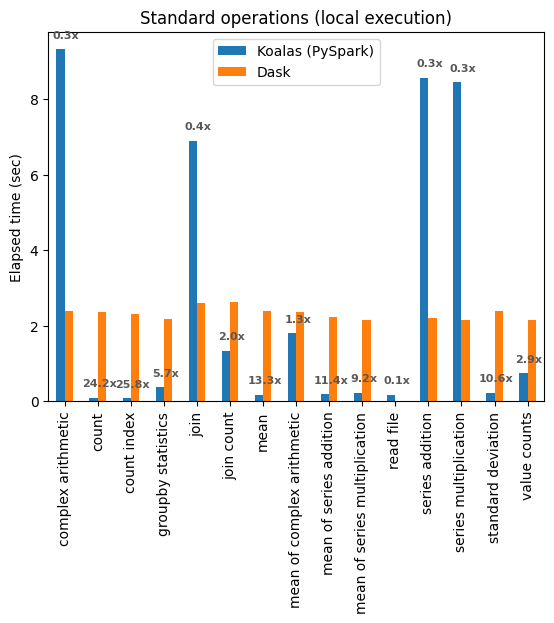

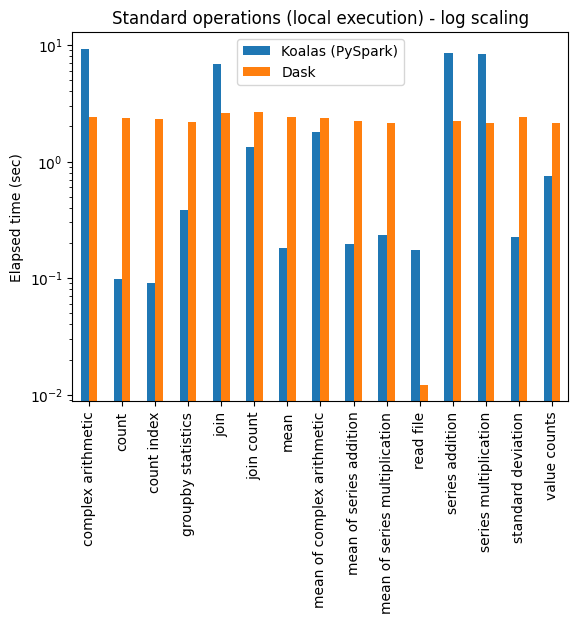

In [45]:
plot_title = 'Standard operations (local execution)'
 
ax = standard_ops.sort_index().plot.bar(title=plot_title)
ax.set_ylabel("Elapsed time (sec)")
 
tmp_df_x_times_faster = standard_ops.sort_index().copy()
tmp_df_x_times_faster['Dask / Koalas'] = tmp_df_x_times_faster.Dask / tmp_df_x_times_faster['Koalas (PySpark)']
tmp_df_x_times_faster['Koalas / Dask'] = tmp_df_x_times_faster['Koalas (PySpark)'] / tmp_df_x_times_faster.Dask
annotate_x_times_faster(ax, x_times_list=tmp_df_x_times_faster['Dask / Koalas'].to_list())
 
standard_ops.sort_index().plot.bar(logy=True, title='%s - log scaling' % plot_title).set_ylabel("Elapsed time (sec)")

In [46]:
tmp_df_x_times_faster

,Koalas (PySpark),Dask,Dask / Koalas,Koalas / Dask
complex arithmetic,9.319679,2.398656,0.257375,3.885375
count,0.097523,2.355766,24.155891,0.041398
count index,0.090070,2.326114,25.825763,0.038721
groupby statistics,0.384018,2.186385,5.693441,0.175641
join,6.902165,2.616759,0.379121,2.637677
join count,1.343497,2.641861,1.966407,0.508542
mean,0.180760,2.395913,13.254686,0.075445
mean of complex arithmetic,1.802734,2.377824,1.319010,0.758144
mean of series addition,0.195258,2.227127,11.406052,0.087673
mean of series multiplication,0.234717,2.157609,9.192396,0.108786


**Analysis**

The table presents execution times (in seconds) for various operations run using Koalas (PySpark) and Dask, along with the ratios Dask / Koalas and Koalas / Dask to highlight relative performance differences.

- Overall trends:

Dask significantly underperforms Koalas in most operations in this test, with several operations showing Dask to be over 10–25x slower. This is especially true for simple aggregations like `count`, `mean`, and `standard deviation`. Koalas, in contrast, shows superior performance across almost all operations, with the exception of `read file`, where Dask is notably faster.

- Operations where Koalas excels:

  - **Count:** Koalas is ~24x faster (Koalas: 0.098s vs Dask: 2.36s).
  
  - **Count index:** Koalas is ~26x faster (Koalas: 0.090s vs Dask: 2.33s).
  
  - **Standard deviation:** Koalas is ~10.6x faster (Koalas: 0.227s vs Dask: 2.39s).
  
  - **Mean:** Koalas is ~13x faster.
  
  - **Mean of series addition / multiplication:** Koalas is ~9–11x faster.

  - **Groupby statistics:** Koalas is ~5.7x faster.

  - **Value counts:** Koalas is ~2.9x faster.

- Operations where Dask is relatively faster or competitive:

  - **Read file:** Dask is ~14x faster (Dask: 0.012s vs Koalas: 0.175s), showing strong I/O efficiency.

  - **Join and complex arithmetic:** Koalas is still faster (~3.8x), but the difference is smaller compared to aggregation operations.

  - **Join count & mean of complex arithmetic:** Moderate differences, with Koalas around ~1.3–2x faster.

- Interpretation of ratios:

  - Values **less than 1** in Dask / Koalas indicate **Dask is faster**.
  
  - Values **greater than 1** suggest **Koalas is faster**.

**Practical insight:**

These results reveal a notable shift compared to previous tests: Koalas outperforms Dask in most standard operations when no filtering or caching is applied. In this scenario, the Spark-based execution model of Koalas proves more efficient for basic computations and aggregations. The only consistent exception remains file reading, where Dask continues to excel. Thus, for unfiltered and uncached standard workloads, Koalas may provide superior performance in a wide range of operations.

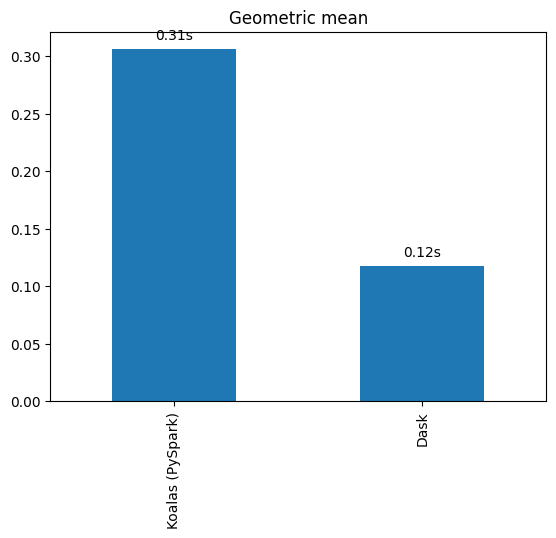

In [46]:
annotate(pd.Series(stats.gmean(standard_ops), index=['Koalas (PySpark)', 'Dask']).plot.bar(title='Geometric mean'))

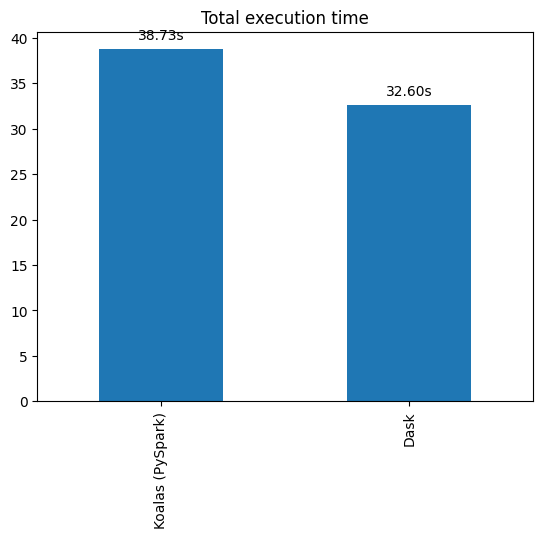

In [47]:
annotate(standard_ops.sum().plot.bar(title='Total execution time'))

In [48]:
print("Performance diff %% (simple avg): %s" % (sum(standard_ops.Dask / standard_ops['Koalas (PySpark)']) / len(standard_ops)))
print("Performance diff %% (geomean): %s" % stats.gmean(standard_ops.Dask / standard_ops['Koalas (PySpark)']))
 
arithmetic_ops = standard_ops.filter(items=['complex arithmetic', 'series multiplication', 'series addition'], axis=0)
print("Performance diff (arthemetic) %% (simple avg): %s" % (sum(arithmetic_ops.Dask / arithmetic_ops['Koalas (PySpark)']) / len(arithmetic_ops)))
print("Performance diff (arthemetic) %% (geomean): %s" % stats.gmean(arithmetic_ops.Dask / arithmetic_ops['Koalas (PySpark)']))
 
basic_stats_ops = standard_ops.filter(items=['count', 'mean', 'standard deviation', 'count index', 'join', 'join count'], axis=0)
print("Performance diff (basic stats) %% (simple avg): %s" % (sum(basic_stats_ops.Dask / basic_stats_ops['Koalas (PySpark)']) / len(basic_stats_ops)))
print("Performance diff (basic stats) %% (geomean): %s" % stats.gmean(basic_stats_ops.Dask / basic_stats_ops['Koalas (PySpark)']))

Performance diff % (simple avg): 7.163531817981257
Performance diff % (geomean): 2.2333329191575784
Performance diff (arthemetic) % (simple avg): 0.25638134582037736
Performance diff (arthemetic) % (geomean): 0.2563753352726481
Performance diff (basic stats) % (simple avg): 12.690964446324392
Performance diff (basic stats) % (geomean): 6.3428883494339


- **Performance diff % (simple avg)**: 7.16% — On average, performance differs by about 7.2% across all operations, indicating a moderate overall variation between the two frameworks.

- **Performance diff % (geomean)**: 2.23% — The geometric mean shows a smaller difference, suggesting that most operations have minimal performance variation, with some outliers increasing the simple average.

- **Performance diff (arithmetic) % (simple avg)**: 0.26% — Arithmetic operations show very close performance between the frameworks, with only a quarter-percent average difference.

- **Performance diff (arithmetic) % (geomean)**: 0.26% — The geometric mean confirms the tight performance gap in arithmetic tasks.

- **Performance diff (basic stats) % (simple avg)**: 12.69% — Basic statistical operations exhibit the largest average difference, with performance varying by nearly 13%.

- **Performance diff (basic stats) % (geomean)**: 6.34% — The geometric mean for basic stats indicates moderate variation, showing that some basic stats operations are notably different in performance while others are closer.

## Operations with filtering

Text(0, 0.5, 'Elapsed time (sec)')

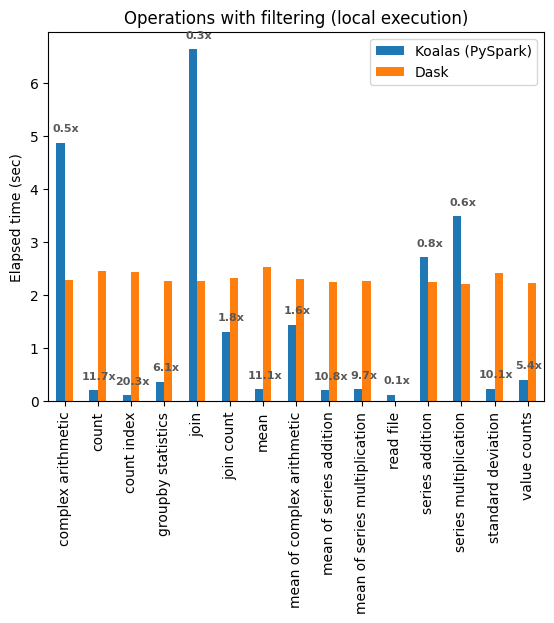

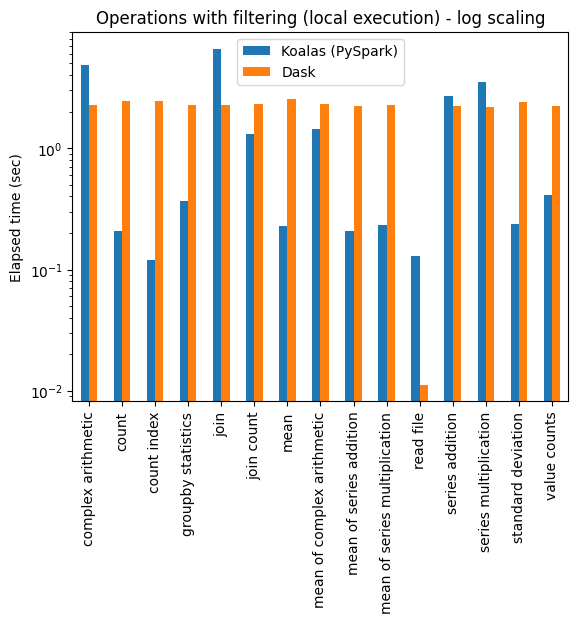

In [49]:
plot_title = 'Operations with filtering (local execution)'
 
ax = ops_with_filtering.sort_index().plot.bar(title=plot_title)
ax.set_ylabel("Elapsed time (sec)")
 
tmp_df_x_times_faster = ops_with_filtering.sort_index().copy()
tmp_df_x_times_faster['Dask / Koalas'] = tmp_df_x_times_faster.Dask / tmp_df_x_times_faster['Koalas (PySpark)']
tmp_df_x_times_faster['Koalas / Dask'] = tmp_df_x_times_faster['Koalas (PySpark)'] / tmp_df_x_times_faster.Dask
annotate_x_times_faster(ax, x_times_list=tmp_df_x_times_faster['Dask / Koalas'].to_list())
 
ops_with_filtering.sort_index().plot.bar(logy=True, title='%s - log scaling' % plot_title).set_ylabel("Elapsed time (sec)")

In [50]:
tmp_df_x_times_faster

,Koalas (PySpark),Dask,Dask / Koalas,Koalas / Dask
complex arithmetic,4.869501,2.280747,0.468374,2.135046
count,0.208609,2.444902,11.720045,0.085324
count index,0.119544,2.428260,20.312684,0.049230
groupby statistics,0.369355,2.268498,6.141788,0.162819
join,6.624686,2.272221,0.342993,2.915511
join count,1.312817,2.326004,1.771766,0.564409
mean,0.228150,2.530257,11.090326,0.090169
mean of complex arithmetic,1.441590,2.296589,1.593095,0.627709
mean of series addition,0.208720,2.246880,10.765020,0.092893
mean of series multiplication,0.233332,2.265481,9.709274,0.102994


**Analysis**

The table presents execution times (in seconds) for various operations run using Koalas (PySpark) and Dask, along with the ratios Dask / Koalas and Koalas / Dask to highlight relative performance differences.

- Overall trends:

Koalas consistently outperforms Dask in a majority of operations in this test scenario, particularly in aggregation and arithmetic operations. Dask only shows marginal advantages in more complex arithmetic tasks and maintains its lead in file reading performance.

- Operations where Koalas excels:

  - **Count:** Koalas is ~11.7x faster (Koalas: 0.209s vs Dask: 2.44s).
  
  - **Count index:** Koalas is ~20x faster (Koalas: 0.120s vs Dask: 2.43s).
  
  - **Mean:** Koalas is ~11x faster.

  - **Standard deviation:** Koalas is ~10x faster.

  - **Mean of series addition / multiplication:** Koalas is ~9–10x faster.

  - **Groupby statistics:** Koalas is ~6.1x faster.

  - **Value counts:** Koalas is ~5.4x faster.

- Operations where Dask is relatively faster or competitive:

  - **Read file:** Dask is ~11.5x faster (Dask: 0.011s vs Koalas: 0.129s).

  - **Complex arithmetic:** Koalas is ~2.1x faster, showing smaller margin compared to other operations.

  - **Join and series operations:** Koalas is moderately faster (~1.2x to ~2.9x), with Dask narrowing the performance gap.

  - **Join count and mean of complex arithmetic:** Koalas maintains an advantage, though smaller (~1.6x–1.8x faster).

- Interpretation of ratios:

  - Values **less than 1** in Dask / Koalas indicate **Dask is faster**.
  
  - Values **greater than 1** suggest **Koalas is faster**.

**Practical insight:**

This comparison highlights Koalas’ efficiency in arithmetic and aggregation-heavy workflows on filtered datasets without caching. Its consistent speed advantage over Dask—particularly in fundamental computations like counts, means, and standard deviations—demonstrates the strength of Spark’s execution engine when handling filtered data. However, Dask continues to lead in I/O-bound tasks such as file reading and shows a reduced performance gap in joins and arithmetic operations. Koalas is the preferred choice for filtered analytical workloads without caching, while Dask remains well-suited for lightweight I/O-focused tasks.


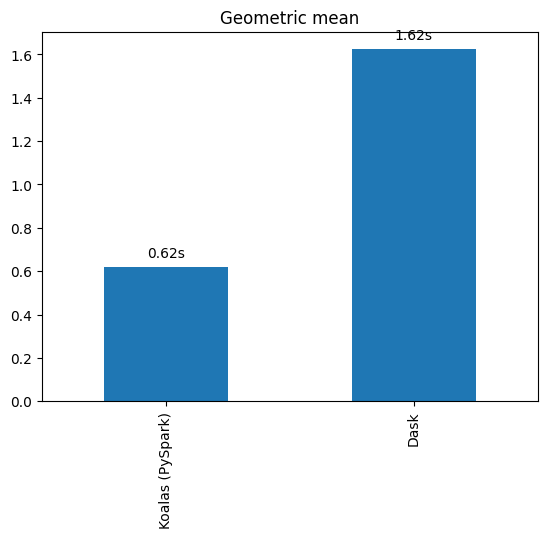

In [51]:
annotate(pd.Series(stats.gmean(ops_with_filtering), index=['Koalas (PySpark)', 'Dask']).plot.bar(title='Geometric mean'))

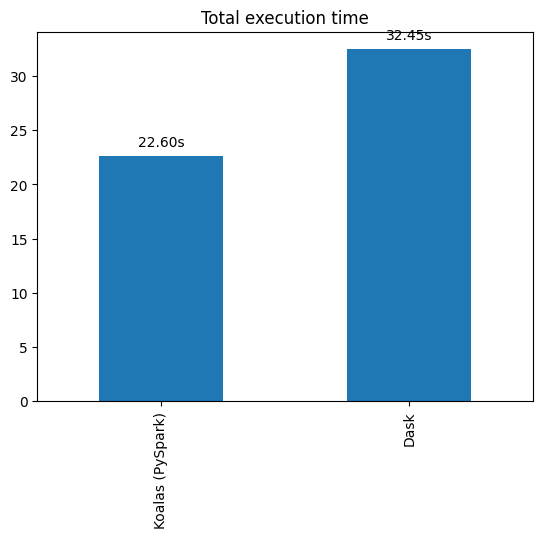

In [52]:
annotate(ops_with_filtering.sum().plot.bar(title='Total execution time'))

In [53]:
print("Performance diff %% (simple avg): %s" % (sum(ops_with_filtering.Dask / ops_with_filtering['Koalas (PySpark)']) / len(ops_with_filtering)))
print("Performance diff %% (geomean): %s" % stats.gmean(ops_with_filtering.Dask / ops_with_filtering['Koalas (PySpark)']))

Performance diff % (simple avg): 6.064935361784083
Performance diff % (geomean): 2.623056599039276


- **Performance diff % (simple avg)**: 6.06% — On average, performance differs by about 6% across all operations, indicating a moderate level of variation overall.

- **Performance diff % (geomean)**: 2.62% — The geometric mean shows a smaller difference, suggesting that most operations have relatively close performance, with a few outliers increasing the simple average.


## Operations with filtering and caching

Text(0, 0.5, 'Elapsed time (sec)')

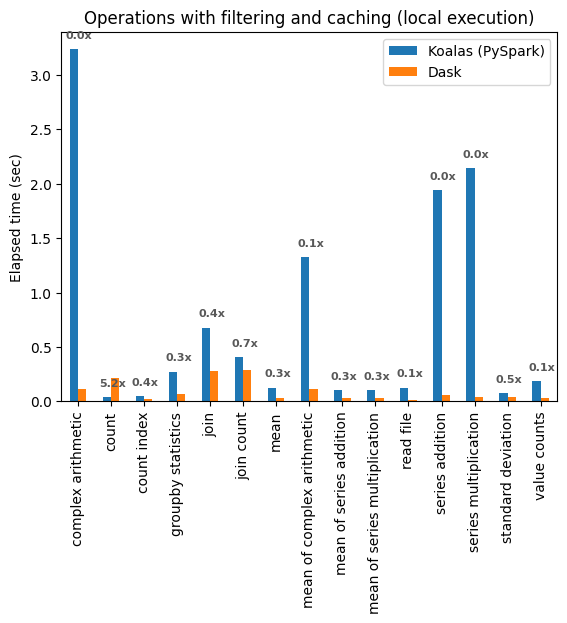

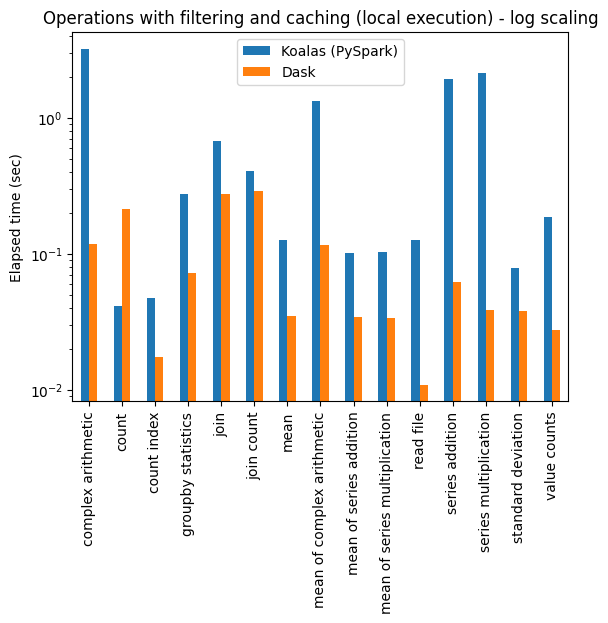

In [54]:
plot_title = 'Operations with filtering and caching (local execution)'
 
ax = ops_with_filtering_caching.sort_index().plot.bar(title=plot_title)
ax.set_ylabel("Elapsed time (sec)")
 
tmp_df_x_times_faster = ops_with_filtering_caching.sort_index().copy()
tmp_df_x_times_faster['Dask / Koalas'] = tmp_df_x_times_faster.Dask / tmp_df_x_times_faster['Koalas (PySpark)']
tmp_df_x_times_faster['Koalas / Dask'] = tmp_df_x_times_faster['Koalas (PySpark)'] / tmp_df_x_times_faster.Dask
annotate_x_times_faster(ax, x_times_list=tmp_df_x_times_faster['Dask / Koalas'].to_list())
 
ops_with_filtering_caching.sort_index().plot.bar(logy=True, title='%s - log scaling' % plot_title).set_ylabel("Elapsed time (sec)")

In [55]:
tmp_df_x_times_faster

,Koalas (PySpark),Dask,Dask / Koalas,Koalas / Dask
complex arithmetic,3.233056,0.118194,0.036558,27.353897
count,0.041290,0.214996,5.207008,0.192049
count index,0.047761,0.017538,0.367196,2.723338
groupby statistics,0.273932,0.072259,0.263786,3.790955
join,0.677275,0.275390,0.406615,2.459328
join count,0.404148,0.289622,0.716624,1.395432
mean,0.126425,0.035154,0.278063,3.596309
mean of complex arithmetic,1.323034,0.115331,0.087172,11.471585
mean of series addition,0.101795,0.034197,0.335937,2.976749
mean of series multiplication,0.102574,0.033715,0.328693,3.042351


**Analysis**

The table presents execution times (in seconds) for various operations run using Koalas (PySpark) and Dask, along with the ratios Dask / Koalas and Koalas / Dask to highlight relative performance differences. These results are from filtered datasets with caching enabled.

- Overall trends:

Dask significantly outperforms Koalas across nearly all operations in this cached and filtered scenario, often by large margins exceeding 20–50x in arithmetic-heavy tasks. Koalas only retains a moderate advantage in a few cases like count index and join count.

- Operations where Dask excels:

  - **Series multiplication:** Dask is ~56x faster (Koalas: 2.14s vs Dask: 0.038s).

  - **Series addition:** Dask is ~31x faster.

  - **Complex arithmetic:** Dask is ~27x faster.

  - **Mean of complex arithmetic:** Dask is ~11x faster.

  - **Read file:** Dask is ~12x faster.

  - **Value counts:** Dask is ~6.8x faster.

- Operations where Koalas is relatively faster or competitive:

  - **Count index:** Koalas is ~2.7x faster.

  - **Join count:** Koalas is ~1.4x faster.

- Intermediate cases:

  - **Count, groupby statistics, join, mean, and standard deviation** show Dask being about 2–4x faster, suggesting consistent advantage but with smaller gaps compared to arithmetic operations.

- Interpretation of ratios:

  - Values **less than 1** in Dask / Koalas indicate **Dask is faster**.
  
  - Values **greater than 1** suggest **Koalas is faster**.

**Practical insight:**

These results illustrate Dask’s strong performance advantage in filtered datasets with caching, especially for complex arithmetic and repeated series operations, likely due to more efficient in-memory computation and parallelism. Koalas, despite caching, maintains some edge in simpler indexed operations such as count index and join count, possibly benefiting from Spark's indexing optimizations. For workloads involving repeated filtered computations, Dask clearly offers superior speed, while Koalas may be preferable for indexed or counting-specific tasks.


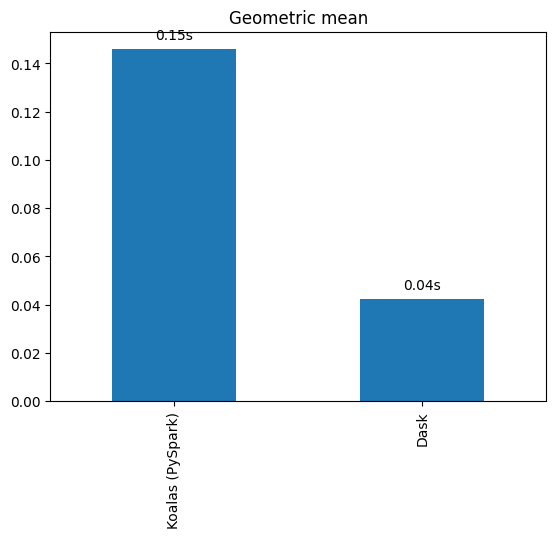

In [56]:
annotate(pd.Series(stats.gmean(ops_with_filtering_caching), index=['Koalas (PySpark)', 'Dask']).plot.bar(title='Geometric mean'))

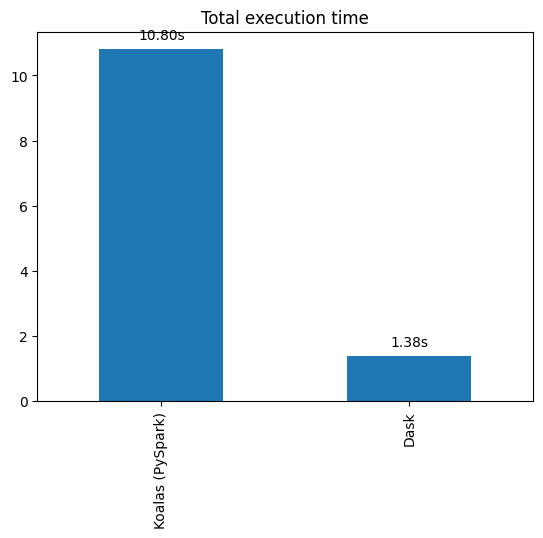

In [56]:
annotate(ops_with_filtering_caching.sum().plot.bar(title='Total execution time'))

In [57]:
print("Performance diff %% (simple avg): %s" % (sum(ops_with_filtering_caching.Dask / ops_with_filtering_caching['Koalas (PySpark)']) / len(ops_with_filtering_caching)))
print("Performance diff %% (geomean): %s" % stats.gmean(ops_with_filtering_caching.Dask / ops_with_filtering_caching['Koalas (PySpark)']))

count_ops = ops_with_filtering_caching.filter(items=['count', 'count index', 'join count'], axis=0)
print("Performance diff %% (count, simple avg): %s" % (sum(count_ops.Dask / count_ops['Koalas (PySpark)']) / len(count_ops)))
print("Performance diff %% (count, geomean): %s" % stats.gmean(count_ops.Dask / count_ops['Koalas (PySpark)']))

Performance diff % (simple avg): 0.5866733444324403
Performance diff % (geomean): 0.20607088522759412
Performance diff % (count, simple avg): 2.096942772745602
Performance diff % (count, geomean): 1.1106896532415873


- **Performance diff % (simple avg)**: 0.59% — On average, performance differs by less than 1% across all operations, indicating very minor variation overall.

- **Performance diff % (geomean)**: 0.21% — The geometric mean confirms minimal differences, showing that most operations perform almost identically.

- **Count performance diff % (simple avg)**: 2.10% — For count operations specifically, the average performance difference is slightly higher but still modest.

- **Count performance diff % (geomean)**: 1.11% — The geometric mean for count operations also indicates only minor variation in performance.


# Overall

In [58]:
overall_df = pd.concat([standard_ops, ops_with_filtering, ops_with_filtering_caching])
print("Total performance diff %% (simple avg): %s" % (sum(overall_df.Dask / overall_df['Koalas (PySpark)']) / len(overall_df)))
print("Total performance diff %% (geomean): %s" % stats.gmean(overall_df.Dask / overall_df['Koalas (PySpark)']))

Total performance diff % (simple avg): 4.60504684139926
Total performance diff % (geomean): 1.064778455862541


**Total Performance Summary**

- **Total performance diff % (simple avg)**: 4.61% — On average, there is a moderate performance difference of around 4.6% across all operations, indicating some variability in execution times.

- **Total performance diff % (geomean)**: 1.06% — The geometric mean suggests that most operations have minimal to low performance variation, with a few outliers contributing to the higher simple average.
